In [1]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely import wkt

## Exploratory Data Analysis for Tree Survival Prediction

This project uses TreeO2 data to understand and predict tree survival rates across different farms in Timor-Leste. Survival outcomes are explored through charts and visual analysis alongside environmental conditions such as rainfall, temperature, soil pH, elevation, and slope to identify patterns, risks, and limiting factors that affect tree survival. These insights are then used to train a machine learning model that predicts tree survival likelihood before planting, and helps field staff make better planting decisions.

### Load and combine TreeO2 (Dec 5) data files

#### Input Files
 The following files must be placed in a datasets/TreeO2 (Dec5) directory in the same directory as this notebook (datascience/notebooks/) before running. They are not committed to the repository due to privacy reasons and must be sourced from MS Teams at: Planting optimisation tool > Shared > Datasets > TreeO2 (Dec 5)

Files:
- GS4210_Baguia_Tree_Data_1.csv
- GS4210_Baguia_Tree_Data_2.csv
- GS4210_Baguia_Tree_Data_3.csv
- GS4210_Baguia_Tree_Data_4.csv
- GS4210_Baguia_Tree_Data_5.csv
- GS4210_Baguia_Tree_Data_6.csv
- GS11743_CCC_Covalima_Tree_Data (1).csv
- GS11800_TV_Baucau_Tree_Data (1).csv
- GS11801_NETIL_Liquica_Tree_Data (1).csv
- RM_Lautem-Lospalos_Tree_Data.csv
- RM_Quelicai-Laga_Tree_Data.csv
- RM_Viqueque-Uatucarbau-Uatulari_Tree_Data.csv

#### Output Files
Running this notebook exports the following files (committed):
- datascience/data/treeo2_dec5_cleaned.csv.gz - cleaned TreeO2 data that can be used for survivability and growth modelling.

In [2]:
# Load all TreeO2 (Dec 5) CSV files
tree_files = [
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_1.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_2.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_4.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_5.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_6.csv",
    "datasets/TreeO2 (Dec 5)/GS4210_Baguia_Tree_Data_3.csv",
    "datasets/TreeO2 (Dec 5)/GS11743_CCC_Covalima_Tree_Data (1).csv",
    "datasets/TreeO2 (Dec 5)/GS11800_TV_Baucau_Tree_Data (1).csv",
    "datasets/TreeO2 (Dec 5)/GS11801_NETIL_Liquica_Tree_Data (1).csv",
    "datasets/TreeO2 (Dec 5)/RM_Lautem-Lospalos_Tree_Data.csv",
    "datasets/TreeO2 (Dec 5)/RM_Quelicai-Laga_Tree_Data.csv",
    "datasets/TreeO2 (Dec 5)/RM_Viqueque-Uatucarbau-Uatulari_Tree_Data.csv",
]

# Read each file and store in a list
df_list = []

for f in tree_files:
    df_tmp = pd.read_csv(f, dtype=str, low_memory=False)

    # Add farm column based on filename
    df_tmp["farm"] = os.path.basename(f).replace(".csv", "")

    df_list.append(df_tmp)

# Combine all TreeO2 (Dec 5) files into one DataFrame
treeo2_dec5_df = pd.concat(df_list, ignore_index=True)

### Remove Duplicates

In [3]:
# Remove all duplicate rows from DataFrame and reset the index
treeo2_dec5_df = treeo2_dec5_df.drop_duplicates().reset_index(drop=True)

# Confirm that no duplicates remain
treeo2_dec5_df.duplicated().sum()

np.int64(0)

### Clean and prepare the TreeO2 (Dec 5) dataset

In [4]:
# Drop farm column
treeo2_dec5_df = treeo2_dec5_df.drop(columns=["farm", "scanned_to_farmer_id"], errors="ignore")

# Fill missing species names with blank text
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].fillna("")

# Remove everything inside the brackets
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace(r"\(.*?\)", "", regex=True)

# Remove all spaces
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace(" ", "")

# Fix hyphen spacing (from Ai- mahony to Ai-mahony)
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace("- ", "-")
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.replace(" -", "-")

# Capitialise the tree species
treeo2_dec5_df["tree_species"] = treeo2_dec5_df["tree_species"].str.capitalize()

# Convert trunk circumference to numeric and drop rows without any entry
treeo2_dec5_df["trunk_circumference"] = pd.to_numeric(treeo2_dec5_df["trunk_circumference"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["trunk_circumference"])

# Convert planted_year to integer dropping rows without any entry
treeo2_dec5_df["planted_year"] = pd.to_numeric(treeo2_dec5_df["planted_year"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["planted_year"])
treeo2_dec5_df["planted_year"] = treeo2_dec5_df["planted_year"].astype(int)

# Convert planted_month to integer dropping rows without any entry
treeo2_dec5_df["planted_month"] = pd.to_numeric(treeo2_dec5_df["planted_month"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["planted_month"])
treeo2_dec5_df["planted_month"] = treeo2_dec5_df["planted_month"].astype(int)

# Convert scan_date to datetime object
treeo2_dec5_df["scan_date"] = pd.to_datetime(treeo2_dec5_df["scan_date"])

# Convert latitude and longitude to numeric values
treeo2_dec5_df[["latitude", "longitude"]] = treeo2_dec5_df[["latitude", "longitude"]].apply(pd.to_numeric, errors="coerce")

# Convert farmer_card_id to integer dropping rows without any entry
treeo2_dec5_df["farmer_card_id"] = pd.to_numeric(treeo2_dec5_df["farmer_card_id"], errors="coerce")
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["farmer_card_id"])
treeo2_dec5_df["farmer_card_id"] = treeo2_dec5_df["farmer_card_id"].astype(int)

# Standardise known species errors in TreeO2 dataset
species_aliases = {
    "eucalyptus": "Ai-bubur (mutin)",
    "ai-kamelii": "Ai-kamelli",
    "ai-bubur": "Ai-bubur (mutin)",
}

tree_species_clean = treeo2_dec5_df["tree_species"].fillna("").astype(str).str.strip()

tree_species_norm = tree_species_clean.str.lower()
for alias_norm, canonical_name in species_aliases.items():
    tree_species_clean = tree_species_clean.mask(tree_species_norm.eq(alias_norm), canonical_name)

treeo2_dec5_df["tree_species"] = tree_species_clean

### Detecting recycled fob_id

In [5]:
# Detecting recycled fob_ids
# ====================== Settings ==================================================================
JUMP_THRES = 50  # Max distance moved (metres) before flagging
CIRC_DROP_THRES = 0.8  # Minimum fraction of tree circumference drop to flag — filters measurement noise


# Helper function for Haversine distance (approximate metres)
def haversine_vectorized(lat1, lon1, lat2, lon2):
    r = 6371000.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


# Ensure chronological order within each fob_id, reset index for safe duplicated() usage
treeo2_dec5_df = treeo2_dec5_df.sort_values(["fob_id", "scan_date"], kind="mergesort").reset_index(drop=True)

# Group by fob_id
grouped = treeo2_dec5_df.groupby("fob_id", sort=False)

# Previous values within fob_id
treeo2_dec5_df["prev_lat"] = grouped["latitude"].shift(1)
treeo2_dec5_df["prev_lon"] = grouped["longitude"].shift(1)
treeo2_dec5_df["species_prev"] = grouped["tree_species"].shift(1)
treeo2_dec5_df["year_prev"] = grouped["planted_year"].shift(1)
treeo2_dec5_df["circ_prev"] = grouped["trunk_circumference"].shift(1)
treeo2_dec5_df["farm_prev"] = grouped["farmer_card_id"].shift(1)

# First-row mask (after reset_index, duplicated() is positionally safe)
is_first_in_fob = ~treeo2_dec5_df["fob_id"].duplicated()

# Calculate spatial jump distance
treeo2_dec5_df["dist_moved_m"] = haversine_vectorized(treeo2_dec5_df["latitude"], treeo2_dec5_df["longitude"], treeo2_dec5_df["prev_lat"], treeo2_dec5_df["prev_lon"])

# Change flags — all explicitly exclude first row per fob
treeo2_dec5_df["species_changed"] = (treeo2_dec5_df["tree_species"] != treeo2_dec5_df["species_prev"]) & ~is_first_in_fob & treeo2_dec5_df["species_prev"].notna()

treeo2_dec5_df["year_changed"] = (treeo2_dec5_df["planted_year"] != treeo2_dec5_df["year_prev"]) & ~is_first_in_fob & treeo2_dec5_df["year_prev"].notna()

treeo2_dec5_df["circ_dropped"] = (treeo2_dec5_df["trunk_circumference"] < (treeo2_dec5_df["circ_prev"] * CIRC_DROP_THRES)) & ~is_first_in_fob & treeo2_dec5_df["circ_prev"].notna()

treeo2_dec5_df["spatial_jump"] = (treeo2_dec5_df["dist_moved_m"] > JUMP_THRES) & ~is_first_in_fob

# NEW: fob_id appeared on a different farm — very strong recycling signal
treeo2_dec5_df["farm_changed"] = (treeo2_dec5_df["farmer_card_id"] != treeo2_dec5_df["farm_prev"]) & ~is_first_in_fob & treeo2_dec5_df["farm_prev"].notna()

# ====================== Reason labels ============================================================
# Priority order: most-evidence combos first so they aren't masked by simpler rules
conditions = [
    # Farm change combos (strongest signal)
    (treeo2_dec5_df["farm_changed"] & treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["farm_changed"] & treeo2_dec5_df["species_changed"]),
    (treeo2_dec5_df["farm_changed"] & treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["farm_changed"]),
    # Species-change combos
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"] & treeo2_dec5_df["spatial_jump"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["species_changed"] & treeo2_dec5_df["spatial_jump"]),
    (treeo2_dec5_df["species_changed"]),
    # Non-species composites
    (treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"] & treeo2_dec5_df["spatial_jump"]),
    (treeo2_dec5_df["year_changed"] & treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["year_changed"]),
    (treeo2_dec5_df["circ_dropped"]),
    (treeo2_dec5_df["spatial_jump"]),
]
choices = [
    "Farm Transfer + Species + Year",
    "Farm Transfer + Species",
    "Farm Transfer + Year",
    "Farm Transfer Only",
    "Full Reset (Species, Year, Size, Location)",
    "Replacement (Species, Year & Size)",
    "Species + Year Updated",
    "Species + Size Drop",
    "Species + Location Jump",
    "Biological Reset (Species Changed)",
    "Partial Reset (Year, Size & Location)",
    "Standard Replacement (Year & Size)",
    "Admin Update Only (Year Changed)",
    "Size Drop Only",
    "Spatial Shift (Location Jumped)",
]
treeo2_dec5_df["recycle_reason"] = np.select(conditions, choices, default="Normal")

# ====================== Aggregate flags ==========================================================
any_change_cols = ["species_changed", "year_changed", "circ_dropped", "spatial_jump", "farm_changed"]
treeo2_dec5_df["any_change"] = treeo2_dec5_df[any_change_cols].any(axis=1)

# ====================== Life cycle numbering =====================================================
# cumsum within fob: the row where a change is detected becomes row 1 of the new life cycle
treeo2_dec5_df["life_cycle_number"] = treeo2_dec5_df.groupby("fob_id")["any_change"].cumsum().astype(int) + 1

# Unique tree instance identifier
treeo2_dec5_df["tree_instance_id"] = treeo2_dec5_df["fob_id"].astype(str) + "_v" + treeo2_dec5_df["life_cycle_number"].astype(str)

# ====================== is_dead column ===========================================================
# A tree instance is dead if a later life cycle exists for the same fob_id
# (i.e. the fob was recycled, meaning the previous tree died)
max_life_per_fob = treeo2_dec5_df.groupby("fob_id")["life_cycle_number"].transform("max")
treeo2_dec5_df["is_dead"] = (treeo2_dec5_df["life_cycle_number"] < max_life_per_fob).astype(int)

# ====================== checks / summary ==================================================
# FOBs spanning multiple farms (pre-filter check)
farms_per_fob = treeo2_dec5_df.groupby("fob_id")["farmer_card_id"].nunique()
print(f"FOBs spanning multiple farms : {(farms_per_fob > 1).sum()}")

fobs_with_species_change = treeo2_dec5_df.groupby("fob_id")["species_changed"].any()
print(f"FOBs with ≥1 species change  : {int(fobs_with_species_change.sum())}")

fobs_with_any_change = treeo2_dec5_df.groupby("fob_id")["any_change"].any()
print(f"FOBs with ≥1 change (any)    : {int(fobs_with_any_change.sum())}")

# Breakdown by reason at fob level
fob_reason_breakdown = treeo2_dec5_df[treeo2_dec5_df["recycle_reason"] != "Normal"].groupby("recycle_reason")["fob_id"].nunique().sort_values(ascending=False)
print("\nRecycle reason breakdown (unique fob_ids):")
print(fob_reason_breakdown.to_string())

# Per-fob summary
recycled_summary = treeo2_dec5_df.groupby("fob_id")[any_change_cols].any()
recycled_summary["is_recycled"] = recycled_summary.any(axis=1)

# Life cycle distribution
multi_life_counts = treeo2_dec5_df.groupby("fob_id")["life_cycle_number"].max().value_counts().sort_index()
print("\nBreakdown of fob_id life cycles:")
for lives, count in multi_life_counts.items():
    print(f"  {lives} life cycle(s): {count:,} unique fob_ids")

# is_dead summary
print(f"\nTotal tree-instance rows marked is_dead=1 : {treeo2_dec5_df['is_dead'].sum():,}")
print(f"Total tree-instance rows marked is_dead=0 : {(treeo2_dec5_df['is_dead'] == 0).sum():,}")

FOBs spanning multiple farms : 17333
FOBs with ≥1 species change  : 2381
FOBs with ≥1 change (any)    : 42462

Recycle reason breakdown (unique fob_ids):
recycle_reason
Spatial Shift (Location Jumped)       16826
Farm Transfer Only                    15319
Size Drop Only                         7372
Farm Transfer + Year                   1942
Biological Reset (Species Changed)     1865
Species + Size Drop                     193
Farm Transfer + Species + Year          150
Species + Location Jump                 118
Farm Transfer + Species                  77

Breakdown of fob_id life cycles:
  1 life cycle(s): 549,378 unique fob_ids
  2 life cycle(s): 36,138 unique fob_ids
  3 life cycle(s): 5,932 unique fob_ids
  4 life cycle(s): 362 unique fob_ids
  5 life cycle(s): 28 unique fob_ids
  7 life cycle(s): 1 unique fob_ids
  19 life cycle(s): 1 unique fob_ids

Total tree-instance rows marked is_dead=1 : 56,594
Total tree-instance rows marked is_dead=0 : 961,648


#### Get the most recent records for every unique tree instance

In [6]:
# This ensures we only count each tree (or recycled version) once.
latest_tree_stats = treeo2_dec5_df.sort_values("scan_date").groupby("tree_instance_id").tail(1)

# Generate the Status Summary
status_summary = latest_tree_stats["is_dead"].value_counts()

# Calculate Percentages for context
status_percent = latest_tree_stats["is_dead"].value_counts(normalize=True) * 100

# Combine into a readable table
summary_df = pd.DataFrame({"Total Trees": status_summary, "Percentage (%)": status_percent.round(2)})

print("\n=== Tree Inventory Summary ===")
print(summary_df)


=== Tree Inventory Summary ===
         Total Trees  Percentage (%)
is_dead                             
0             591840           92.32
1              49224            7.68


### Update longitude and latitude

In [7]:
# Treat sentinel values as missing
treeo2_dec5_df[["latitude", "longitude"]] = treeo2_dec5_df[["latitude", "longitude"]].replace(-1, pd.NA)

# Compute the farm centroids
farm_centroids = treeo2_dec5_df.groupby("farmer_card_id").agg({"latitude": "mean", "longitude": "mean"})
print(f"Farms with no centroid value: {farm_centroids.isnull().sum().max()}")

# Fill missing latitude using the centroids per farm
treeo2_dec5_df["latitude"] = treeo2_dec5_df["latitude"].combine_first(treeo2_dec5_df["farmer_card_id"].map(farm_centroids["latitude"]).astype(float))

# Fill missing longitude using reference longitude per farm
treeo2_dec5_df["longitude"] = treeo2_dec5_df["longitude"].combine_first(treeo2_dec5_df["farmer_card_id"].map(farm_centroids["longitude"]).astype(float))

# Drop rows with missing latitude or longitude
treeo2_dec5_df = treeo2_dec5_df.dropna(subset=["latitude", "longitude"])

# Show remaining missing values for latitude and longitude
print(f"Farms with no centroid value after cleaning: {treeo2_dec5_df.isnull().sum()[['latitude', 'longitude']].max()}")

Farms with no centroid value: 16
Farms with no centroid value after cleaning: 0


In [8]:
# Remove columns that are not required
cols_to_drop = [
    "fob_id",
    "farmer_card_id",
    "prev_lat",
    "prev_lon",
    "species_prev",
    "year_prev",
    "circ_prev",
    "farm_prev",
    "farm_changed",
    "dist_moved_m",
    "species_changed",
    "year_changed",
    "circ_dropped",
    "spatial_jump",
    "recycle_reason",
    "any_change",
    "life_cycle_number",
    "max_life_for_this_fob",
    "is_alive",
    "days_since_last_scan",
]
treeo2_dec5_df = treeo2_dec5_df.drop(columns=cols_to_drop, errors="ignore")
treeo2_dec5_df = treeo2_dec5_df.reset_index(drop=True)

### Add farm_id

In [9]:
# Read farm boundaries
farms = pd.read_csv("../../backend/src/scripts/data/farm_boundaries_master.csv").rename(columns={"external_id": "farm_id", "boundary": "geometry"})
farms["geometry"] = farms["geometry"].apply(wkt.loads)

farms_gdf = gpd.GeoDataFrame(farms, geometry="geometry", crs="EPSG:4326")

cols_to_exclude = ["longitude", "latitude"]

# Build point geometries (x=lon, y=lat)
points_gdf = gpd.GeoDataFrame(
    treeo2_dec5_df.drop(columns=cols_to_exclude).copy(),
    geometry=gpd.points_from_xy(treeo2_dec5_df["longitude"], treeo2_dec5_df["latitude"]),
    crs="EPSG:4326",  # set to WGS84 as the lat/lon are geographic degrees
)

points_proj = points_gdf.to_crs("EPSG:32752")
farms_proj = farms_gdf.to_crs("EPSG:32752")

# Returns only points that fall within at least one polygon
joined = gpd.sjoin(points_proj, farms_proj[["farm_id", "geometry"]], how="left", predicate="within")

# Prepare distance column now (important)
joined["nearest_dist"] = pd.NA
unmatched_idx = joined.index[joined["farm_id"].isna()]
joined_nearest = gpd.sjoin_nearest(points_proj.loc[unmatched_idx], farms_proj[["farm_id", "geometry"]], how="left", distance_col="nearest_dist")

p95_dist = joined_nearest["nearest_dist"].dropna().quantile(0.95)

print(f"95th percentile nearest distance: {p95_dist:.0f} meters")

ABSOLUTE_MAX = 5000  # meters
distance_cutoff = min(p95_dist, ABSOLUTE_MAX)

print(f"Using distance cutoff: {distance_cutoff:.0f} meters")

too_far = joined_nearest["nearest_dist"] > distance_cutoff

joined_nearest.loc[too_far, "farm_id"] = pd.NA
joined_nearest.loc[too_far, "nearest_dist"] = pd.NA

joined.loc[unmatched_idx] = joined_nearest.reindex(joined.columns, axis=1)
joined["match_type"] = "unmatched"
joined.loc[joined["farm_id"].notna(), "match_type"] = "within"
joined.loc[joined["nearest_dist"].notna(), "match_type"] = "nearest"

print(joined["match_type"].value_counts())

# Drop trees with no farm match (either within or nearest)
joined = joined.dropna(subset=["farm_id"])
joined["farm_id"] = joined["farm_id"].astype(int)

95th percentile nearest distance: 2128 meters
Using distance cutoff: 2128 meters
match_type
nearest      652138
within       331385
unmatched     34323
Name: count, dtype: int64


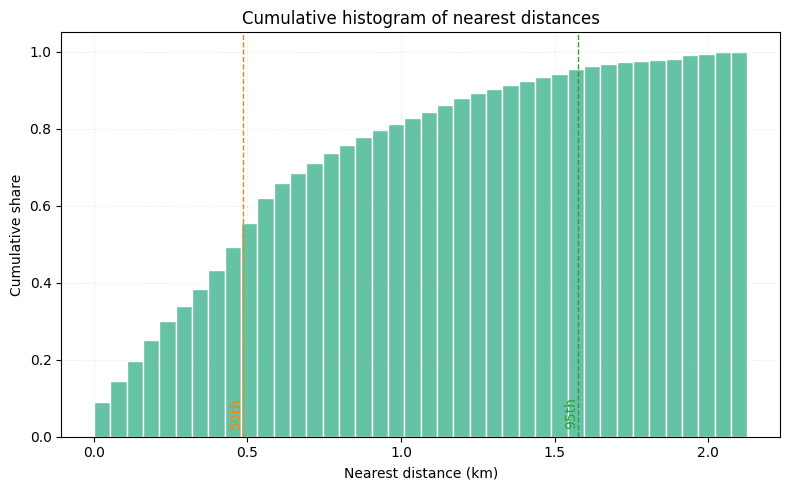

In [10]:
x_km = joined_nearest["nearest_dist"].dropna().astype(float) / 1000.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    x_km,
    bins=40,
    cumulative=True,
    density=True,  # scales to 0–1 so it reads like an ECDF
    color="#66c2a5",
    edgecolor="white",
)
# Optional: annotate key percentiles
p50 = np.percentile(x_km, 50)
p95 = np.percentile(x_km, 95)
ax.axvline(p50, color="#ff7f0e", linestyle="--", linewidth=1)
ax.axvline(p95, color="#2ca02c", linestyle="--", linewidth=1)
ax.text(p50, 0.02, "50th", rotation=90, va="bottom", ha="right", color="#ff7f0e")
ax.text(p95, 0.02, "95th", rotation=90, va="bottom", ha="right", color="#2ca02c")
ax.set_xlabel("Nearest distance (km)")
ax.set_ylabel("Cumulative share")
ax.set_title("Cumulative histogram of nearest distances")
ax.grid(alpha=0.3, linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

In [11]:
result_df = joined.drop(columns=[c for c in joined.columns if c not in treeo2_dec5_df.columns and c not in ["farm_id"]])

In [12]:
# Reorder result_df columns using exact column names only
column_order = [
    "farm_id",
    "tree_instance_id",
    "tree_species",
    "planted_year",
    "planted_month",
    "scan_date",
    "trunk_circumference",
    "is_dead",
]

remaining_cols = [c for c in result_df.columns if c not in column_order]
result_df = result_df[column_order + remaining_cols]

result_df.to_csv(os.path.join("../data/treeo2_dec5_cleaned.csv.gz"), index=False)